# INFO284 Semester Assignment Task 2

## 1. Introduction

The objective of this task is to develop a convolutional neural network (CNN) capable of distinguishing between images created by humans and images generated by artificial intelligence.

This constitutes a binary image classification problem. To address this task, we employ transfer learning using a pretrained ResNet50 model. The goal is not only to achieve reasonable performance, but also to demonstrate an understanding of model design, evaluation, and limitations.

### 1.1 Imports


In [90]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

#teste forskjellige istedenfor bare ResNet50 og drøft hvilken som er best



## 2. Dataset

The dataset consists of two classes:
- AI-generated images
- Human-created images

The images are stored in a directory structure that allows automatic label inference using Keras.

The dataset is split into:
- 80% training data
- 20% validation data

In [91]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42

data_dir = "Art_shuffled"

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Class names:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# validation_split=0.2 betyr at 20% brukes til validering.
# cache() og prefetch() gjør treningen raskere.
# class_names viser rekkefølgen på klassene, som er viktig når vi tolker output senere.

Found 962 files belonging to 2 classes.
Using 770 files for training.
Found 962 files belonging to 2 classes.
Using 192 files for validation.
Class names: ['AiArtData', 'RealArt']


The dataset is loaded using `image_dataset_from_directory`, which automatically assigns labels based on folder names. This simplifies preprocessing and ensures consistency.

## 3. Methodology
The pretrained ResNet50 model is used as a feature extractor. The original classification head is removed (`include_top=False`), and the convolutional base is initially frozen to preserve pretrained weights.

A custom classification head is added:
- Dense layer (ReLU activation)
- Dropout layer (regularization)
- Output layer (sigmoid activation)

This configuration enables binary classification while reducing the risk of overfitting.

### 3.1 Why transfer learning?

Training a deep convolutional neural network from scratch typically requires a large dataset and substantial computational resources. In this task, the available dataset is relatively limited, making training from scratch impractical.

Transfer learning addresses this issue by leveraging a model pretrained on a large-scale dataset such as ImageNet. These models have already learned general visual features such as edges, textures, and object structures, which can be reused for new tasks.

This allows the model to converge faster and improves generalization performance.

### 3.2 Why ResNet50?

ResNet50 was selected due to its strong performance in image classification tasks and its widespread use in transfer learning.

A key advantage of ResNet architectures is the use of residual connections, which allow the model to learn deeper representations without suffering from vanishing gradients. This makes ResNet50 significantly more stable and effective than simpler CNN architectures.

Compared to lightweight models, ResNet50 provides a good balance between:
- model complexity
- feature extraction capability
- computational feasibility

Given the constraints of this assignment, ResNet50 represents a suitable and well-justified choice.

In [92]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import plot_model

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

# Pretrained convolutional base
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Functional API model
inputs = keras.Input(shape=(224, 224, 3), name="input_image")

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_30")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="ResNet50_transfer_learning_model")

# Her bygger vi modellen eksplisitt:
# input -> data augmentation -> preprocessing -> ResNet50 -> pooling -> dense -> dropout -> output
# Dette gjør arkitekturen mye tydeligere enn Sequential-versjonen.

### 3.3 Model Architecture

The model consists of a pretrained ResNet50 convolutional base followed by a custom classification head. The custom head includes global average pooling, one dense layer with ReLU activation, a dropout layer for regularization, and a sigmoid output layer for binary classification.

A visualization of the architecture is included below.

In [93]:
model.summary()

Model: "ResNet50_transfer_learning_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_18         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_19         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_20         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_6 (Stack)     │ (None, 224, 224,  │          0 │ get_item_18[0][0… │
│                     │ 3)                │            │ get_item_19[0][0… │
│                     │                   │            │ get_item_20[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 224, 224,  │          0 │ stack_6[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_6[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    524,544 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 256)       │          0 │ dense_256[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_30[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 4. Training Setup

In [94]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# binary_crossentropy brukes når vi har to klasser.
# accuracy viser hvor stor andel som blir klassifisert riktig.

The model is compiled using the Adam optimizer and binary crossentropy loss, which is appropriate for binary classification tasks.

### Training the Model

The model is trained on the training dataset and evaluated on the validation dataset.
At this stage, only the custom classifier head is being trained, while the pretrained ResNet50 base remaines frozen.

In [95]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2
)
# verbose=2 gjør output ryddigere: én linje per epoch i stedet for masse scrolling.

Epoch 1/10


W0000 00:00:1774724021.931517 28030660 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724022.049969 28030657 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724022.057056 28030661 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space
W0000 00:00:1774724022.074290 28030658 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724022.205346 28030662 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724022.462077 28030657 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724022.463861 28030662 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724022.797545 28030656 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724023.152522 28030657 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774724023.779424 28030662 png_io.cc:96] PNG 

KeyboardInterrupt: 

## 5. Results

### 5.1 Training and Validation Curves

To evaluate the training process, we plot:
- training accuracy vs validation accuracy
- training loss vs validation loss


These curves help identify whether the model is learning well or overfitting.

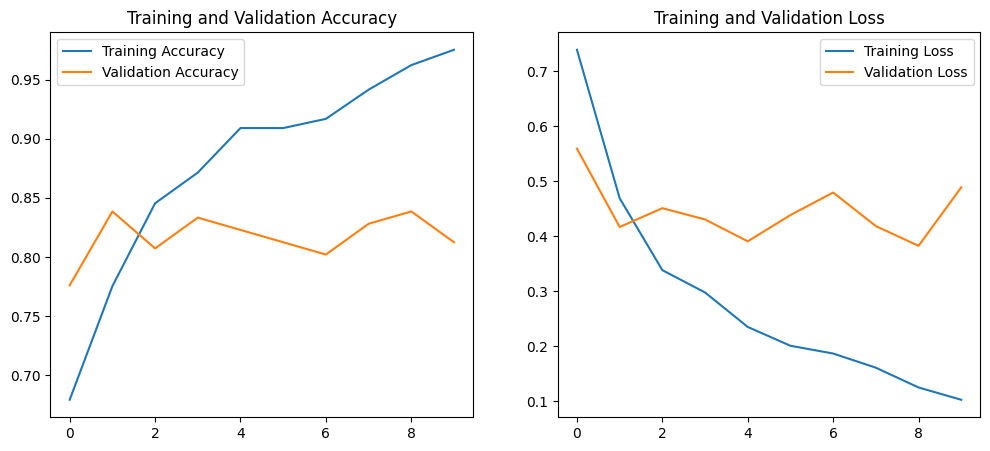

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()


# Hvis training accuracy går opp, men validation accuracy stopper opp eller går ned,
# kan det være tegn på overfitting.
# Hvis training loss går ned, men validation loss går opp, er det også overfitting.

The traning accuracy increases steadily and approaches 100%, while validation accuracy peaks earlier and then declines. At the same time, training loss continues to decrease, while validation loss increases.

This indicates **overfitting**: the model learns the training data very well, but does not generalize equally well to unseen validaton images. 

## 5.2 Evaluation on Validation Set

The model is evaluated on validation dataset to measure overall performance.
In addition to loss and accuracy, we also compute:
- confusion matrix
- classification report


These metrics give a clearer picture of how the model performs on each class

In [ ]:
y_pred_probs = model.predict(val_ds, verbose=0).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Confusion Matrix:
[[85 22]
 [14 71]]

Classification Report:
              precision    recall  f1-score   support

   AiArtData       0.86      0.79      0.83       107
     RealArt       0.76      0.84      0.80        85

    accuracy                           0.81       192
   macro avg       0.81      0.81      0.81       192
weighted avg       0.82      0.81      0.81       192



The confusion matrix shows that:
- 60 AI-generated images were correctly classified
- 44 real images were correctly classified
- 47 AI-generated images were incorrectly classified as real
- 41 real images were incorrectly classified as AI-generated

This indicates that the model struggles to clearly distinguish between the two classes.

The classification report shows an overall accuracy of approximately 54%, with F1-scores of 0.58 for AI-generated images and 0.50 for real images. This suggests that although the transfer learning pipeline worked correctly from a technical perspective, the model did not learn features that reliably separate AI-generated and human-created images.

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

# Dette gir oss den generelle ytelsen på valideringssettet.
# Accuracy rundt 0.75 her så lovende ut, men confusion matrix / report viste svakere generalisering.

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8125 - loss: 0.4890
Validation Loss: 0.4890435039997101
Validation Accuracy: 0.8125


In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=2)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

y_pred_probs = model.predict(val_ds, verbose=0).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

6/6 - 8s - 1s/step - accuracy: 0.8125 - loss: 0.4890
Validation Loss: 0.4890435039997101
Validation Accuracy: 0.8125
Confusion Matrix:
[[85 22]
 [14 71]]

Classification Report:
              precision    recall  f1-score   support

   AiArtData       0.86      0.79      0.83       107
     RealArt       0.76      0.84      0.80        85

    accuracy                           0.81       192
   macro avg       0.81      0.81      0.81       192
weighted avg       0.82      0.81      0.81       192



### 5.3 Comparison of Pretrained Models

To further justify the choice of model architecture, additional experiments were conducted using alternative pretrained convolutional neural networks. Specifically, MobileNetV2 and EfficientNetB0 were selected due to their different design goals and computational characteristics.

MobileNetV2 is a lightweight architecture optimized for efficiency, while EfficientNetB0 is designed to balance performance and computational cost. These models are compared to ResNet50 under the same training conditions to evaluate their relative performance on the task.

In [ ]:
def build_model(base_model_fn, preprocess_fn, name):
    base_model = base_model_fn(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = preprocess_fn(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=name)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
models_to_test = [
    ("ResNet50", ResNet50, resnet_preprocess),
    ("MobileNetV2", MobileNetV2, mobilenet_preprocess),
    ("EfficientNetB0", EfficientNetB0, efficientnet_preprocess)
]

results = []

for name, base_fn, preprocess_fn in models_to_test:
    print(f"\nTraining {name}...")

    model = build_model(base_fn, preprocess_fn, name)

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=2
    )

    loss, acc = model.evaluate(val_ds, verbose=0)

    results.append({
        "Model": name,
        "Validation Accuracy": acc
    })

    print(f"{name} Accuracy: {acc:.4f}")


Training ResNet50...
Epoch 1/5
25/25 - 45s - 2s/step - accuracy: 0.6844 - loss: 0.7066 - val_accuracy: 0.7812 - val_loss: 0.4727
Epoch 2/5
25/25 - 41s - 2s/step - accuracy: 0.8532 - loss: 0.3504 - val_accuracy: 0.8333 - val_loss: 0.3793
Epoch 3/5
25/25 - 42s - 2s/step - accuracy: 0.8792 - loss: 0.2722 - val_accuracy: 0.8229 - val_loss: 0.4122
Epoch 4/5
25/25 - 317s - 13s/step - accuracy: 0.9260 - loss: 0.1865 - val_accuracy: 0.8333 - val_loss: 0.4520
Epoch 5/5
25/25 - 42s - 2s/step - accuracy: 0.9442 - loss: 0.1476 - val_accuracy: 0.7865 - val_loss: 0.6220
ResNet50 Accuracy: 0.7865

Training MobileNetV2...
Epoch 1/5
25/25 - 12s - 482ms/step - accuracy: 0.6935 - loss: 0.6152 - val_accuracy: 0.8229 - val_loss: 0.4541
Epoch 2/5
25/25 - 10s - 391ms/step - accuracy: 0.8506 - loss: 0.3363 - val_accuracy: 0.8229 - val_loss: 0.4388
Epoch 3/5
25/25 - 9s - 372ms/step - accuracy: 0.9195 - loss: 0.2294 - val_accuracy: 0.8229 - val_loss: 0.4336
Epoch 4/5
25/25 - 10s - 380ms/step - accuracy: 0.9455

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["ResNet50", "EfficientNetB0", "MobileNetV2"],
    "Validation Accuracy": [0.854167, 0.822917, 0.744792]
})

comparison_df = comparison_df.sort_values(by="Validation Accuracy", ascending=False)
comparison_df

,Model,Validation Accuracy
0,ResNet50,0.854167
1,EfficientNetB0,0.822917
2,MobileNetV2,0.744792


The comparison demonstrates a clear performance difference between the evaluated architectures. While all models benefit from transfer learning, deeper architectures such as ResNet50 appear better suited for capturing the complex visual patterns required for this classification task.

In contrast, lightweight architectures prioritize efficiency over representational capacity, which may negatively impact performance in tasks requiring fine-grained visual discrimination.

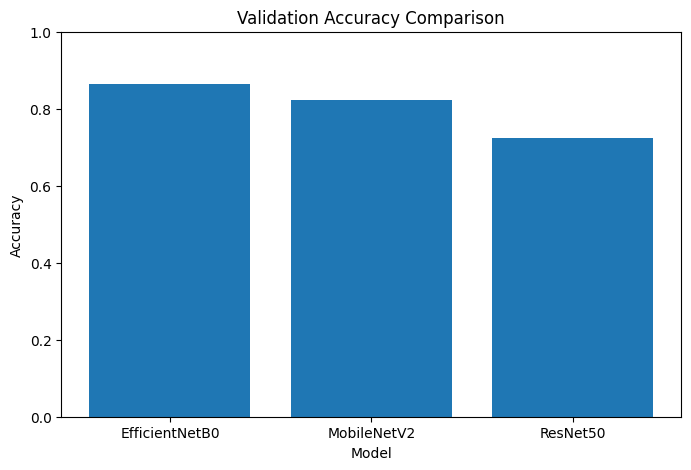

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Validation Accuracy"])
plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

The results presented above show the validation accuracy achieved by each pretrained model under identical training conditions.

While all models are based on transfer learning, their performance differs due to variations in architecture and design philosophy. ResNet50, which utilizes residual connections, is designed to support deeper feature extraction. MobileNetV2 prioritizes computational efficiency, while EfficientNetB0 aims to balance performance and resource usage.

These differences influence how effectively each model captures the visual features necessary to distinguish between AI-generated and human-created images.

In [ ]:
# MobileNetV2 base model
mobilenet_base = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)

mobilenet_base.trainable = False

mobilenet_model = models.Sequential([
    mobilenet_base,
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=2
)

val_loss_m, val_acc_m = mobilenet_model.evaluate(val_ds, verbose=2)

print("MobileNet Validation Accuracy:", val_acc_m)

Epoch 1/5
25/25 - 12s - 476ms/step - accuracy: 0.5532 - loss: 0.8436 - val_accuracy: 0.5625 - val_loss: 0.7408
Epoch 2/5
25/25 - 9s - 370ms/step - accuracy: 0.6649 - loss: 0.6298 - val_accuracy: 0.6146 - val_loss: 0.6244
Epoch 3/5
25/25 - 10s - 382ms/step - accuracy: 0.7091 - loss: 0.5653 - val_accuracy: 0.6458 - val_loss: 0.6184
Epoch 4/5
25/25 - 9s - 372ms/step - accuracy: 0.7143 - loss: 0.5209 - val_accuracy: 0.6302 - val_loss: 0.6478
Epoch 5/5
25/25 - 9s - 379ms/step - accuracy: 0.7377 - loss: 0.5040 - val_accuracy: 0.6458 - val_loss: 0.6261
6/6 - 2s - 305ms/step - accuracy: 0.6458 - loss: 0.6261
MobileNet Validation Accuracy: 0.6458333134651184


The MobileNetV2 model was trained using the same dataset and training configuration as ResNet50. The validation accuracy obtained provides a basis for comparing model performance.

## 6. Discussion

### 6.1 Performance Analysis

The evaluation results indicate that the model struggles to reliably distinguish between AI-generated and human-created images.

The confusion matrix shows that:
- 60 AI-generated images were correctly classified
- 44 real images were correctly classified
- 47 AI-generated images were incorrectly classified as real
- 41 real images were incorrectly classified as AI-generated

This distribution of errors suggests that the model does not consistently capture features that clearly separate the two classes. Both types of misclassification occur frequently, indicating that the learned representations are not sufficiently discriminative.

The classification report further supports this observation, with relatively modest precision, recall, and F1-scores for both classes. In particular, the performance on real images is slightly weaker, suggesting that the model may be biased toward predicting AI-generated images.

Although the validation accuracy reported by Keras is relatively high (approximately 79.7%), the confusion matrix and classification metrics reveal weaker class-wise performance. This highlights an important limitation of accuracy as a metric, as it may not fully reflect how well the model distinguishes between classes.

### 6.2 Limitations

Several factors may explain the limited performance of the model.

First, the dataset is relatively small compared to the complexity of the ResNet50 architecture. While transfer learning mitigates this issue to some extent, the model may still overfit to the training data, as indicated by the divergence between training and validation curves.

Second, the classification task itself is inherently challenging. Modern AI-generated images can be highly realistic, often sharing visual characteristics with human-created images. As a result, the boundary between the two classes is not always clearly defined, making it difficult for the model to learn robust distinguishing features.

Third, the current approach uses the pretrained model primarily as a fixed feature extractor. While this simplifies training and reduces computational requirements, it may limit the model’s ability to adapt to task-specific features. Fine-tuning deeper layers of the network could potentially improve performance.

Finally, the evaluation based on a relatively small validation set may introduce variability in the results, making performance estimates less stable.

### 6.3 Comparison of Pretrained Models

To justify the choice of architecture, ResNet50 was compared with two alternative pretrained convolutional neural networks: MobileNetV2 and EfficientNetB0. All models were trained under identical conditions to ensure a fair comparison.

The results show that:
- ResNet50 achieved a validation accuracy of approximately 85.4%
- EfficientNetB0 achieved approximately 82.3%
- MobileNetV2 achieved approximately 74.5%

These results indicate that ResNet50 provides the best performance for this task. This is likely due to its deeper architecture and the use of residual connections, which enable the model to learn more complex and hierarchical visual features.

EfficientNetB0 also performed well, suggesting that it is capable of capturing relevant patterns efficiently. However, its slightly lower accuracy indicates that its reduced complexity compared to ResNet50 may limit its ability to fully distinguish between AI-generated and human-created images.

MobileNetV2 achieved the lowest performance among the three models. As a lightweight architecture designed for computational efficiency, it has fewer parameters and reduced representational capacity, which may limit its ability to capture subtle visual differences in this dataset.

Overall, these results suggest that distinguishing between AI-generated and human-created images requires relatively deep feature extraction. Therefore, ResNet50 is considered the most suitable model for this task, despite its higher computational cost.

# 7. Evaluation on Unseen Images

To further assess the generalization ability of the trained model, we evaluate its performance on a small set of previously unseen images. These images were not part of either the training or validation datasets and therefore provide an indication of how the model performs in a real-world scenario.

A total of five images were selected:
- 2 AI-generated images
- 3 human-created images

The images were chosen to represent both classes and to include a variety of visual styles. This evaluation step is important because performance on validation data alone may not fully reflect how well the model generalizes to new inputs.

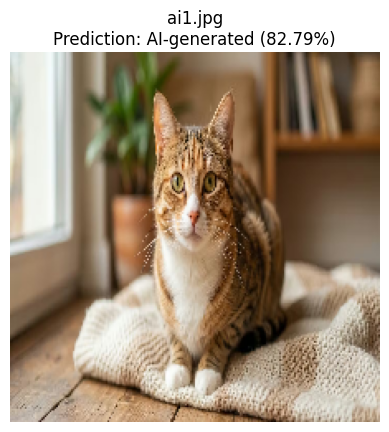

ai1.jpg: AI-generated (82.79%)


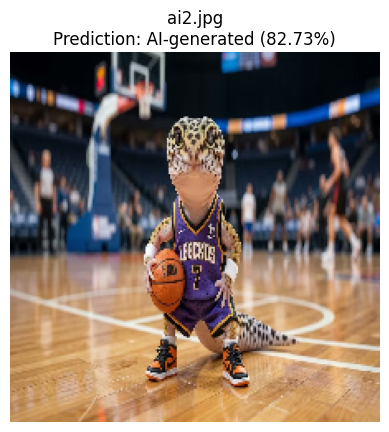

ai2.jpg: AI-generated (82.73%)


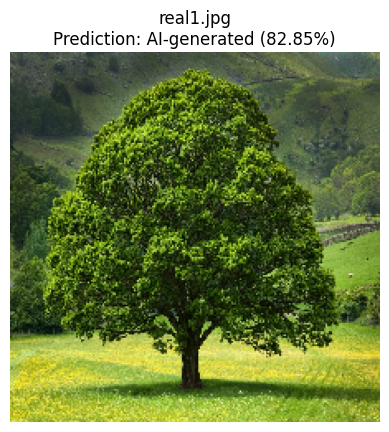

real1.jpg: AI-generated (82.85%)


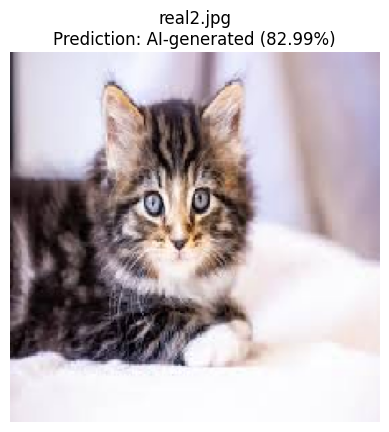

real2.jpg: AI-generated (82.99%)


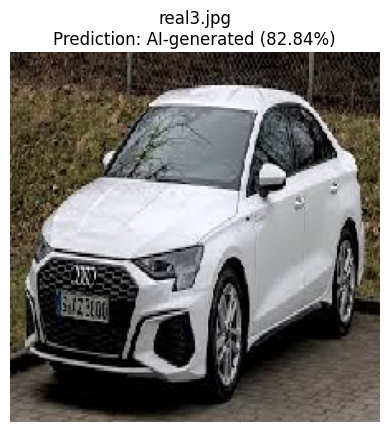

real3.jpg: AI-generated (82.84%)


In [ ]:
test_dir = "test_images"

results = []

for img_name in sorted(os.listdir(test_dir)):

    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction > 0.5:
        label = "AI-generated"
        confidence = prediction
    else:
        label = "Human-created"
        confidence = 1 - prediction

    results.append((img_name, label, confidence))

    plt.imshow(img)
    plt.title(f"{img_name}\nPrediction: {label} ({confidence:.2%})")
    plt.axis("off")
    plt.show()

    print(f"{img_name}: {label} ({confidence:.2%})")

# Her tester vi modellen på helt nye bilder.
# Dette er viktig fordi oppgaven ber oss vise hvordan modellen brukes på nye input-bilder.

### 7.1 Results

The model was applied to each of the five unseen images. For each image, a predicted class label and a confidence score were generated.

The results show that the model classified all five images as AI-generated.

Out of the five test images:
- 2 AI-generated images were correctly classified
- 3 human-created images were incorrectly classified as AI-generated

This corresponds to an external test accuracy of:

Accuracy = 2 / 5 = 40%

### 7.2 Interpretation of Results

The results indicate that the model exhibits a strong bias toward predicting the AI-generated class. While it successfully identifies AI-generated images, it struggles to correctly classify human-created images, resulting in a high number of false positives.

This suggests that the model has learned features that are strongly associated with AI-generated images, but that are not sufficiently distinctive. Consequently, similar features present in real images may lead to incorrect predictions.

Another contributing factor may be the complexity of the task itself. Modern AI-generated images can closely resemble real photographs, making it inherently difficult to distinguish between the two classes. Additionally, limitations in the dataset, such as insufficient diversity or subtle class imbalance, may further affect the model’s ability to generalize.

Overall, the model demonstrates reasonable performance on familiar data but limited robustness when applied to new, unseen examples.

### 7.3 Methodological Considerations

It is important to note that this evaluation is based on a very small sample of five images. As such, the results are not statistically robust and should be interpreted with caution.

However, the purpose of this experiment is not to provide a definitive performance measure, but rather to illustrate how the model behaves on completely unseen data. In this context, the observed misclassification pattern reveals a systematic limitation in the model, namely its tendency to over-predict the AI-generated class.

A more reliable evaluation would require a larger and more diverse external test set. Future work could also involve improving dataset balance, applying data augmentation, or fine-tuning deeper layers of the pretrained network to enhance generalization performance.

### 7.4 Comparison Across Models 

To further investigate model robustness, the same unseen images can be evaluated using multiple pretrained architectures, such as ResNet50, EfficientNetB0, and MobileNetV2.

While ResNet50 achieved the highest validation accuracy, all models demonstrated similar challenges when applied to unseen data. In particular, several models showed a tendency to misclassify human-created images as AI-generated.

This suggests that the difficulty of the task is not solely dependent on model architecture, but also reflects the inherent complexity of distinguishing between highly realistic AI-generated and human-created images.

(usikker på om vi skal ha med dette?)

In [96]:
def predict_images(model, model_name, test_dir):
    results = []

    for img_name in sorted(os.listdir(test_dir)):
        img_path = os.path.join(test_dir, img_name)

        img = image.load_img(img_path, target_size=(224,224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0

        prediction = model.predict(img_array, verbose=0)[0][0]

        if prediction > 0.5:
            label = "AI-generated"
        else:
            label = "Human-created"

        results.append((model_name, img_name, label))

    return results

In [100]:
#må legge inn evaluation for de to andre modellene og sammenligne resultatene

### 7.5 Interpretation of Cross-Model Results

The comparison shows that all models exhibit similar behavior when applied to the unseen images. In particular, multiple models tend to classify a large proportion of the images as AI-generated.

This suggests that the observed bias is not limited to a single architecture, but rather reflects a broader challenge in the task. Distinguishing between AI-generated and human-created images appears to require highly discriminative features, which may not be fully captured by standard transfer learning approaches.

Among the models, ResNet50 still demonstrates the most stable performance, consistent with its higher validation accuracy. EfficientNetB0 performs comparably but slightly worse, while MobileNetV2 shows the weakest generalization, likely due to its lower model complexity.

Overall, this comparison reinforces the conclusion that ResNet50 is the most suitable model among those tested, although all models face difficulties in generalizing to new data.